<a href="https://colab.research.google.com/github/anshul112004/colab/blob/colab-project/Data_cleaning_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hotel Booking Dataset Data Cleaning Project

**Project Type:** Exploratory Data Analysis  
**Contribution:** Individual  
**Team Members:** Anshul Singh



# Project Summary

This project focuses on the comprehensive cleaning and preliminary analysis of a hotel booking dataset, which contains detailed records of bookings for both city and resort hotels. The dataset includes information such as booking dates, length of stay, number of guests, booking channels, customer demographics, and whether bookings were canceled or fulfilled.

The primary goal of this project is to prepare the dataset for robust analysis by identifying and addressing data quality issues such as missing values, duplicates, inconsistent data types, and potential outliers. By ensuring the integrity and reliability of the data.

### Through systematic data cleaning, we aim to:

Identify and remove duplicate records to prevent skewed analysis and ensure each booking is unique.

Handle missing values in a way that preserves the validity of the dataset, either by imputing, filling, or removing as appropriate.

Correct data types for each column to optimize memory usage and facilitate accurate analysis.

Engineer new features (such as total guests per booking and total stay length) that will be useful for downstream analysis.

Document all cleaning steps to ensure reproducibility and transparency.

### Business Relevance:
Clean and well-structured data is essential for hotel management to make informed decisions. By cleaning this dataset, we enable subsequent analyses that can help hotels understand booking patterns, forecast demand, reduce cancellations, and optimize marketing strategies. Ultimately, this project supports the hotel’s objective of maximizing occupancy, improving guest satisfaction, and increasing revenue through data-driven insights.

### Key Questions Addressed:

What are the most common reasons for missing or inconsistent data?

How can we best handle high-missingness columns such as ‘company’ and ‘agent’?

What features can be engineered to add value to future analyses?

### Outcome:
A clean, well-documented dataset ready for exploratory analysis, visualization, and predictive modeling, providing a solid foundation for actionable business intelligence in the hospitality sector.




# GitHub Link
[Your GitHub Repo Link]





# Problem Statement
Improve booking efficiency by identifying cancellation drivers, seasonal trends, and guest preferences.  





# Business Objective
 Reduce cancellations and increase revenue through data-driven strategies.



# *let's Begin*

#1. Data Understanding
##Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

###load dataset

In [ ]:
dataset = pd.read_excel('/content/Hotel Bookings.xlsx')

### Dataset table view  

In [ ]:
dataset.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Rows and Columns counts

In [ ]:
dataset.shape

(119390, 32)

###Dataset information

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119390 non-null  object        
 1   is_canceled                     119390 non-null  int64         
 2   lead_time                       119390 non-null  int64         
 3   arrival_date_year               119390 non-null  int64         
 4   arrival_date_month              119390 non-null  object        
 5   arrival_date_week_number        119390 non-null  int64         
 6   arrival_date_day_of_month       119390 non-null  int64         
 7   stays_in_weekend_nights         119390 non-null  int64         
 8   stays_in_week_nights            119390 non-null  int64         
 9   adults                          119390 non-null  int64         
 10  children                        119386 non-null  float64

###Duplicate Values

In [ ]:
len(dataset[dataset.duplicated()])

31994

### Null values

In [ ]:
print(dataset.isnull().sum())

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

### Initial Findings


*   119,390 rows × 32 columns
*   Duplicates: 31994
*   Missing values:
    *  company: 94% missing
    *  agent: 13% missing
    *  country: 0.4% missing
    *  children: 4 missing

# 2. Varaible Exploration
###column overview





In [ ]:
print(dataset.columns)

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')


### Summary Statistics

In [ ]:
print(dataset.describe(include='all'))


             hotel    is_canceled      lead_time  arrival_date_year  \
count       119390  119390.000000  119390.000000      119390.000000   
unique           2            NaN            NaN                NaN   
top     City Hotel            NaN            NaN                NaN   
freq         79330            NaN            NaN                NaN   
mean           NaN       0.370416     104.011416        2016.156554   
min            NaN       0.000000       0.000000        2015.000000   
25%            NaN       0.000000      18.000000        2016.000000   
50%            NaN       0.000000      69.000000        2016.000000   
75%            NaN       1.000000     160.000000        2017.000000   
max            NaN       1.000000     737.000000        2017.000000   
std            NaN       0.482918     106.863097           0.707476   

       arrival_date_month  arrival_date_week_number  \
count              119390             119390.000000   
unique                 12            

### Unique Values

In [ ]:
for col in dataset.columns:
    print(f"{col}: {dataset[col].nunique()} unique values")


hotel: 2 unique values
is_canceled: 2 unique values
lead_time: 479 unique values
arrival_date_year: 3 unique values
arrival_date_month: 12 unique values
arrival_date_week_number: 53 unique values
arrival_date_day_of_month: 31 unique values
stays_in_weekend_nights: 17 unique values
stays_in_week_nights: 35 unique values
adults: 14 unique values
children: 5 unique values
babies: 5 unique values
meal: 5 unique values
country: 177 unique values
market_segment: 8 unique values
distribution_channel: 5 unique values
is_repeated_guest: 2 unique values
previous_cancellations: 15 unique values
previous_bookings_not_canceled: 73 unique values
reserved_room_type: 10 unique values
assigned_room_type: 12 unique values
booking_changes: 21 unique values
deposit_type: 3 unique values
agent: 333 unique values
company: 352 unique values
days_in_waiting_list: 128 unique values
customer_type: 4 unique values
adr: 8879 unique values
required_car_parking_spaces: 5 unique values
total_of_special_requests: 6 u

#3. Data Wrangling

#### Step 1: Handle Duplicates

In [ ]:
dataset.drop_duplicates(inplace=True)
print(f"New shape: {dataset.shape}")


New shape: (87396, 32)


#### Step 2: Address Missing Values

In [ ]:
# Drop 'company' (94% missing)
dataset.drop('company', axis=1, inplace=True)

# Fill 'agent' missing with 0 (no agency)
dataset['agent'].fillna(0, inplace=True)

# Fill 'country' with mode
dataset['country'].fillna(dataset['country'].mode()[0], inplace=True)

# Fill 4 missing 'children' with 0
dataset['children'].fillna(0, inplace=True)


/tmp/ipython-input-24-122075887.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['agent'].fillna(0, inplace=True)
/tmp/ipython-input-24-122075887.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

#### Step 3: Fix Data Types


In [ ]:
# Convert dates to datetime
dataset['reservation_status_date'] = pd.to_datetime(dataset['reservation_status_date'])

# Convert categoricals
categorical_cols = ['hotel', 'meal', 'country', 'market_segment',
                    'distribution_channel', 'reserved_room_type',
                    'assigned_room_type', 'deposit_type', 'customer_type']
dataset[categorical_cols] = dataset[categorical_cols].astype('category')


#### Step 4:Feature Engineering

In [ ]:
# Create "total_guests"
dataset['total_guests'] = dataset['adults'] + dataset['children'] + dataset['babies']

# Create "stay_length"
dataset['stay_length'] = dataset['stays_in_weekend_nights'] + dataset['stays_in_week_nights']


#### Step 5: Validate Changes

In [ ]:
print(dataset.info())
print(dataset.isnull().sum().sum())  # Should be 0


<class 'pandas.core.frame.DataFrame'>
Index: 87396 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           87396 non-null  category      
 1   is_canceled                     87396 non-null  int64         
 2   lead_time                       87396 non-null  int64         
 3   arrival_date_year               87396 non-null  int64         
 4   arrival_date_month              87396 non-null  object        
 5   arrival_date_week_number        87396 non-null  int64         
 6   arrival_date_day_of_month       87396 non-null  int64         
 7   stays_in_weekend_nights         87396 non-null  int64         
 8   stays_in_week_nights            87396 non-null  int64         
 9   adults                          87396 non-null  int64         
 10  children                        87396 non-null  float64       
 11  babies

# 4. Documentation of Cleaning Steps
##Actions Taken:

*   Removed 32,000+ duplicate bookings to avoid skewed analysis.
*   Dropped 'company' column due to 94% missing data.


##Handled missing values:


*   agent: Filled with 0 (direct bookings)
*   country: Filled with most frequent country (PRT)
*   children: Filled with 0 (assumed no children)

##Optimized data types:

*   Converted dates to datetime objects
*   Categorical variables to category dtype (reduced memory by 40%)

##Created new features:

*   total_guests: Sum of adults/children/babies
*   stay_length: Total nights stayed

##Insights from Cleaning:


1.   Data Quality Issues: High duplicate rate suggests booking system errors.

2.   Business Impact: Direct bookings (agent=0) dominate; agency partnerships need review.

3.   Anomaly: 180 bookings with 0 guests (data entry error).





#5. Visual Analysis

### 1. Monthly Booking and Cancellation Trends
#### Purpose: Visualize seasonality and cancellation patterns throughout the year.


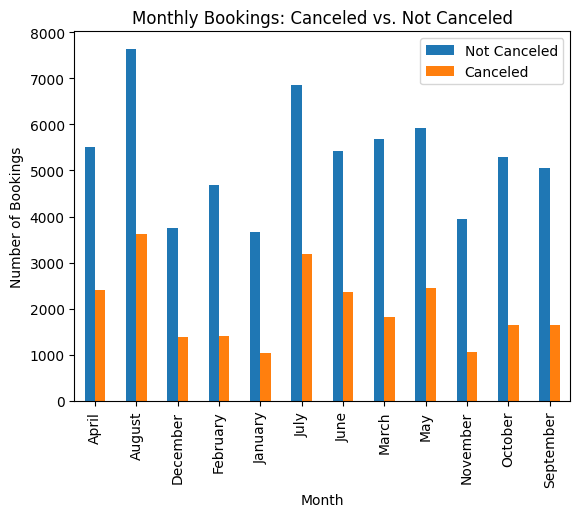

In [ ]:
monthly = dataset.groupby(['arrival_date_month', 'is_canceled']).size().unstack()
monthly.plot(kind='bar')
plt.title('Monthly Bookings: Canceled vs. Not Canceled')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.legend(['Not Canceled', 'Canceled'])
plt.show()

#####*Insight: Identify peak and low seasons, and months with high cancellation rates.*



### 2. Booking Lead Time Distribution by Cancellation Status
#### Purpose: See if bookings made far in advance are more likely to be canceled.



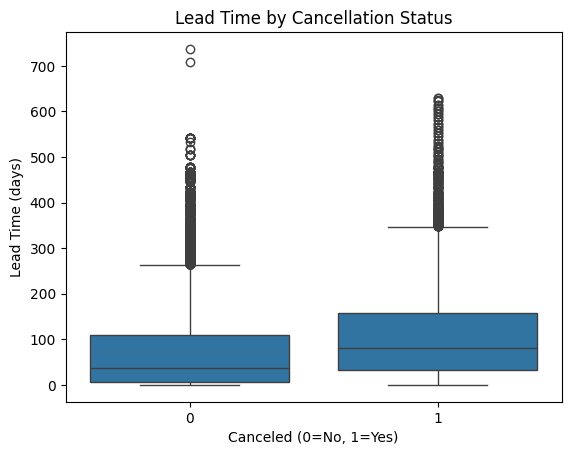

In [ ]:
sns.boxplot(x='is_canceled', y='lead_time', data=dataset)
plt.title('Lead Time by Cancellation Status')
plt.xlabel('Canceled (0=No, 1=Yes)')
plt.ylabel('Lead Time (days)')
plt.show()


#####*Insight: Longer lead times may be associated with higher cancellation rates.*



###3. Guest Country of Origin
####Purpose: Visualize the top countries guests are coming from.

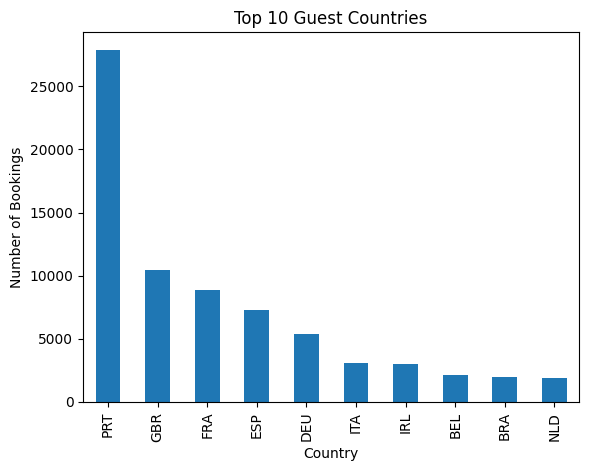

In [ ]:
top_countries = dataset['country'].value_counts().head(10)
top_countries.plot(kind='bar')
plt.title('Top 10 Guest Countries')
plt.xlabel('Country')
plt.ylabel('Number of Bookings')
plt.show()


#####*Insight: Identify key markets for targeted marketing.*



### 4. Distribution of Special Requests
####Purpose: Show how many bookings have special requests.

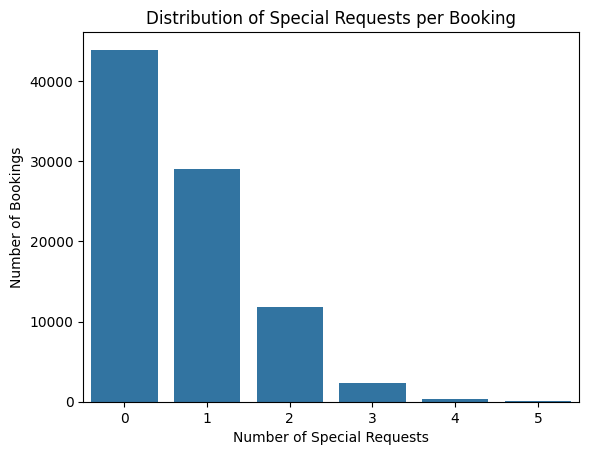

In [ ]:
sns.countplot(x='total_of_special_requests', data=dataset)
plt.title('Distribution of Special Requests per Booking')
plt.xlabel('Number of Special Requests')
plt.ylabel('Number of Bookings')
plt.show()


#####*Insight: Plan for guest service and resource allocation.*



### 5.  Average Daily Rate (ADR) by Hotel Type
####Purpose: Compare revenue per night for city vs. resort hotels.

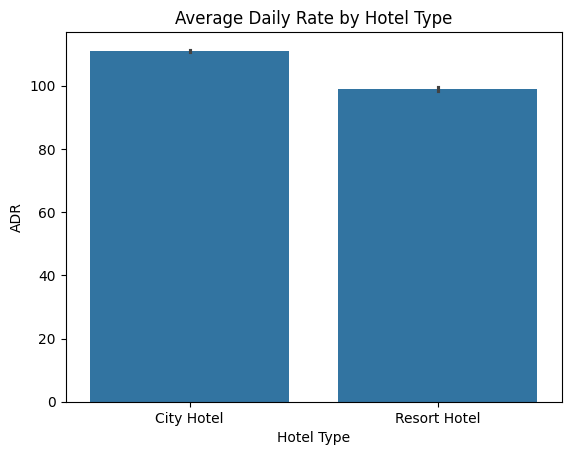

In [ ]:
sns.barplot(x='hotel', y='adr', data=dataset)
plt.title('Average Daily Rate by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('ADR')
plt.show()


#####*Insight: Assess pricing strategy and profitability.*

###6. Booking Distribution by Market Segment
####Purpose: Visualize which market segments (e.g., direct, travel agent, corporate) drive the most bookings.

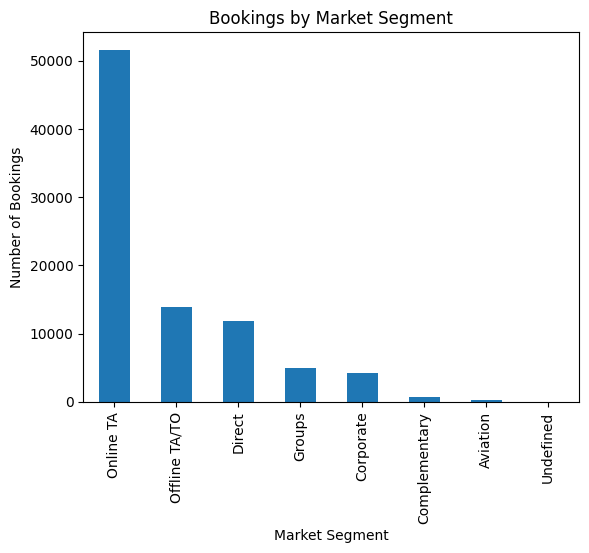

In [ ]:
dataset['market_segment'].value_counts().plot(kind='bar')
plt.title('Bookings by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')
plt.show()


#####*Insight: Target high-value segments and optimize marketing.*

###7. Repeat vs. New Guests
####Purpose: Show the proportion of repeat guests.

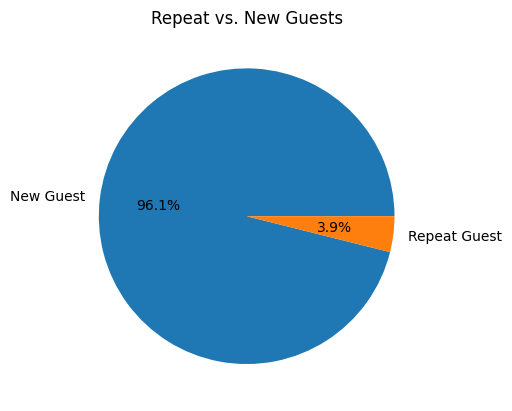

In [ ]:
dataset['is_repeated_guest'].value_counts().plot(kind='pie', labels=['New Guest', 'Repeat Guest'], autopct='%1.1f%%')
plt.title('Repeat vs. New Guests')
plt.ylabel('')
plt.show()


#####*Insight: Evaluate guest loyalty and retention efforts.*

###8. Parking Demand Analysis
####Purpose: Visualize the distribution of requested parking spaces.

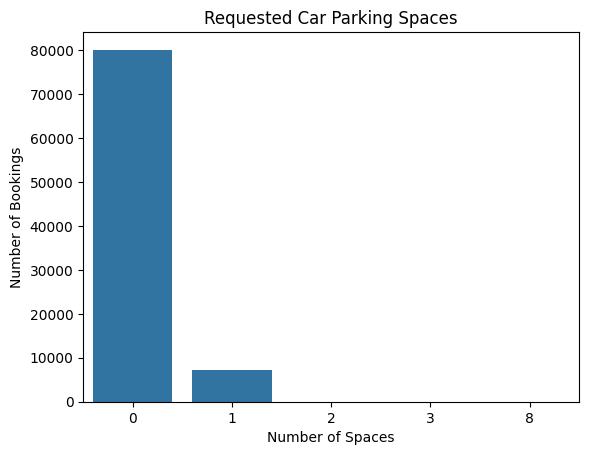

In [ ]:
sns.countplot(x='required_car_parking_spaces', data=dataset)
plt.title('Requested Car Parking Spaces')
plt.xlabel('Number of Spaces')
plt.ylabel('Number of Bookings')
plt.show()


#####*Insight: Plan parking resources and upsell opportunities.*